# Weighting sweep: recency decay × in-person multiplier

Tunes the weighted base model: per-team fit weights `w = exp(−Δt/τ) · m^[in-person]`, normalized to `Σw = N` (`k2dex.loaders.team_weights` — the exact production code path, threaded through `fit_pl_ising` as `sample_weight`).

**Scoring**: leave-one-out completion, on **two held-out future eval sets per fit**:

- **`in_person`** — the most recent in-person event(s). The deployment target ("what serious players bring next"), but typically just one or a few events, so vulnerable to the *in-person-events-resemble-each-other* confound: with in-person events in both train and eval, a large in-person multiplier may just be learning "the previous in-person event predicts the next one".
- **`online`** — all online tournaments on/after the cutoff date. The "current meta" control. A weighting that wins on **both** columns is improving future-meta prediction generally; one that wins only on `in_person` is resemblance (or genuinely in-person-specific structure — undecidable until more in-person events land).

Held-out PLL is reported alongside as the calibration cross-check; read MRR / top-5 / PLL as a panel, not any one scalar.

**Sections**: corpus report (in-person fraction bounds the multiplier's leverage) → out-of-time split → species `(τ, m)` grid (fast first pass) → species @ item grid with uniqueness-masked completion (the production model) → **λ re-sweep at candidate cells** (effective sample size shrinks under decay, so the L2 optimum can move — and cliff-adjacent winners need their λ checked before being trusted).

Runtime: one PL fit per grid cell. Research notebook, run once.

In [1]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from k2dex import tournament_ingest
from k2dex.constants import (
    VOCAB_MIN_TEAM_COUNT, SPECIES_LR_LAMBDA, SPECIES_ITEM_LR_LAMBDA,
)
from k2dex.loaders import team_weights
from k2dex.models import fit_pl_ising

tournaments = tournament_ingest.load_cached_tournaments()
n_teams_total = sum(len(t.teams) for t in tournaments)
ip = [t for t in tournaments if t.tournament_type == "in-person"]
n_ip_teams = sum(len(t.teams) for t in ip)
f_ip = n_ip_teams / n_teams_total

print(f"tournaments:     {len(tournaments)}  ({len(ip)} in-person)")
print(f"teams:           {n_teams_total}  ({n_ip_teams} in-person = {f_ip:.1%})")
print(f"date range:      {tournaments[0].meta.date} .. {tournaments[-1].meta.date}")
print(f"in-person dates: {min(t.meta.date for t in ip)} .. {max(t.meta.date for t in ip)}")
print()
print("multiplier leverage (share of total fit weight that is in-person, no decay):")
for mult in (1.0, 1.5, 2.0, 3.0, 5.0, 10.0):
    share = mult * f_ip / (mult * f_ip + (1 - f_ip))
    print(f"  multiplier {mult:>3g}: {share:.1%}")

tournaments:     198  (3 in-person)
teams:           23608  (3044 in-person = 12.9%)
date range:      2026-04-09T16:00:00.000Z .. 2026-06-15T01:00:00.000Z
in-person dates: 2026-05-30 .. 2026-06-12

multiplier leverage (share of total fit weight that is in-person, no decay):
  multiplier   1: 12.9%
  multiplier 1.5: 18.2%
  multiplier   2: 22.8%
  multiplier   3: 30.8%
  multiplier   5: 42.5%
  multiplier  10: 59.7%


## Out-of-time split: train strictly before the cutoff, two eval sets after

The cutoff is the date of the earliest held-out in-person event. Train = every tournament — both sources — **strictly older** than the cutoff (online events sharing the cutoff date are excluded from train too: conservative, avoids same-day leakage). The recency reference date is the latest *train* date, exactly as production uses the latest corpus date.

Eval sets:
- `in_person`: the held-out in-person event(s) (~30% of in-person teams, whole events, most recent first).
- `online`: every online tournament on/after the cutoff — complementary to train by construction, so no overlap and no leakage.

In [2]:
TEST_IN_PERSON_FRAC = 0.30

ip_sorted = sorted(ip, key=lambda t: t.meta.date)
target = TEST_IN_PERSON_FRAC * n_ip_teams
held_out, acc = [], 0
for t in reversed(ip_sorted):
    held_out.append(t)
    acc += len(t.teams)
    if acc >= target:
        break
held_out = held_out[::-1]
cutoff_date = held_out[0].meta.date

train_tournaments = [t for t in tournaments if t.meta.date < cutoff_date]
train_obs = tournament_ingest.all_team_observations(train_tournaments)
ref_date = max(t.meta.date for t in train_tournaments)

test_in_person_teams = [team.members for t in held_out for team in t.teams]

test_online_tournaments = [
    t for t in tournaments
    if t.tournament_type == "limitless" and t.meta.date >= cutoff_date
]
test_online_teams = [team.members for t in test_online_tournaments for team in t.teams]

n_train_ip = sum(o.tournament_type == "in-person" for o in train_obs)
print(f"cutoff: {cutoff_date}")
print(f"train:  {len(train_obs)} teams from {len(train_tournaments)} tournaments, "
      f"in-person {n_train_ip} = {n_train_ip / len(train_obs):.1%}, latest date {ref_date}")
print(f"in-person eval:  {len(held_out)} in-person events, {len(test_in_person_teams)} teams "
      f"({cutoff_date} .. {held_out[-1].meta.date})")
print(f"online eval: {len(test_online_tournaments)} online events, {len(test_online_teams)} teams "
      f"({min(t.meta.date for t in test_online_tournaments)[:10]} .. "
      f"{max(t.meta.date for t in test_online_tournaments)[:10]})")

cutoff: 2026-06-12
train:  22074 teams from 189 tournaments, in-person 1950 = 8.8%, latest date 2026-06-11T23:00:00.000Z
in-person eval:  1 in-person events, 1094 teams (2026-06-12 .. 2026-06-12)
online eval: 8 online events, 440 teams (2026-06-12 .. 2026-06-15)


## Harness

Vocab is built from **train only** with the raw cutoff and held **fixed across the grid**, so every `(τ, m)` point is scored on identical completion problems. (Production applies a *weighted* cutoff; vocab membership shifts at the tail are a second-order effect this sweep deliberately freezes out.) OOV test teams are dropped, as in `validation.ipynb`.

MF scorer and completion metrics mirror `regularization_sweep.ipynb`. `ESS = (Σw)² / Σw²` tracks how much effective data the weighting leaves — the input to the λ re-sweep. Each grid cell is **one fit scored on both eval sets**.

In [3]:
def teams_to_matrix(teams, key_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for k in team:
            j = key_to_idx.get(k)
            if j is not None:
                X[ti, j] = 1
    return X


def held_out_pll(X_eval, J, h):
    """Mean per-team held-out pseudo-log-likelihood under (J, h)."""
    logits = X_eval @ J + h
    nll_pos = np.logaddexp(0.0, -logits)   # -log sigmoid(logits)
    nll_neg = np.logaddexp(0.0, logits)    # -log(1 - sigmoid(logits))
    ll = -(X_eval * nll_pos + (1 - X_eval) * nll_neg)
    return float(ll.sum() / X_eval.shape[0])


def score_ising_meanfield(held_in_idx, *, J, h, n_iters=200, tol=1e-4, damp=0.5):
    """Damped mean-field marginals, held-in clamped to 1. Mirrors validation.ipynb."""
    V_local = len(h)
    fixed = np.zeros(V_local, dtype=bool)
    fixed[list(held_in_idx)] = True
    m = 1.0 / (1.0 + np.exp(-h))
    m[fixed] = 1.0
    for _ in range(n_iters):
        m_new = 1.0 / (1.0 + np.exp(-(h + J @ m)))
        m_new[fixed] = 1.0
        delta = float(np.max(np.abs(m_new[~fixed] - m[~fixed])))
        m = damp * m_new + (1.0 - damp) * m
        m[fixed] = 1.0
        if delta < tol:
            break
    return m


def effective_sample_size(w):
    return float(w.sum() ** 2 / (w ** 2).sum())


def sweep_grid(X_train_local, lam, evals):
    """One fit per (tau, mult) cell, scored on every eval set.

    evals: list of (label, metric_fn, problems, X_test).
    Returns {(tau, mult): {"ess": ..., label: {mrr, hit1, hit5, pll}, ...}}."""
    results = {}
    for tau in TAU_GRID:
        for mult in MULT_GRID:
            w = team_weights(train_obs, reference_date=ref_date,
                             recency_tau=tau, in_person_multiplier=mult)
            J, h = fit_pl_ising(X_train_local, C=1.0 / lam, sample_weight=w)
            r = {"ess": effective_sample_size(w)}
            for label, metric_fn, probs, X_t in evals:
                mrr, hit1, hit5 = metric_fn(probs, J, h)
                r[label] = dict(mrr=mrr, hit1=hit1, hit5=hit5,
                                pll=held_out_pll(X_t, J, h))
            results[(tau, mult)] = r
            tau_s = "none" if tau is None else f"{tau:g}"
            cols = "  |  ".join(
                f"{label} MRR={r[label]['mrr']:.4f} top1={r[label]['hit1']:.1%} "
                f"top5={r[label]['hit5']:.1%} pll={r[label]['pll']:.2f}"
                for label, *_ in evals
            )
            print(f"tau={tau_s:>5} mult={mult:<4g} ESS={r['ess']:>7.0f}  {cols}")
    return results


def grid_heatmap(results, eval_label, key, title):
    Z = np.array([[results[(tau, m)][eval_label][key] for m in MULT_GRID]
                  for tau in TAU_GRID])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(Z, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(MULT_GRID)), [f"{m:g}" for m in MULT_GRID])
    ax.set_yticks(range(len(TAU_GRID)), ["none" if t is None else f"{t:g}" for t in TAU_GRID])
    ax.set_xlabel("in-person multiplier")
    ax.set_ylabel("recency tau (days)")
    ax.set_title(title)
    for i in range(len(TAU_GRID)):
        for j in range(len(MULT_GRID)):
            ax.text(j, i, f"{Z[i, j]:.4f}", ha="center", va="center",
                    color="white", fontsize=7)
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


def report_best(results, label, eval_labels):
    baseline_key = (None, 1.0)
    if baseline_key in results:
        b = results[baseline_key]
        cols = "  |  ".join(f"{e} MRR={b[e]['mrr']:.4f}" for e in eval_labels)
        print(f"{label}: unweighted baseline   {cols}")
    best_keys = {}
    for e in eval_labels:
        k = max(results, key=lambda kk: results[kk][e]["mrr"])
        best_keys[e] = k
        r = results[k]
        tau_s = "none" if k[0] is None else f"{k[0]:g}"
        cols = "  |  ".join(f"{e2} MRR={r[e2]['mrr']:.4f}" for e2 in eval_labels)
        print(f"{label}: best on {e:<7} tau={tau_s} mult={k[1]:g}  ESS={r['ess']:.0f}   {cols}")
    return best_keys


COMPLETION_SEED = 42

## Species vocab, matrices, completion problems (both eval sets)

In [4]:
train_species = tournament_ingest.species_only_teams([o.members for o in train_obs])

species_counts = Counter(name for team in train_species for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= VOCAB_MIN_TEAM_COUNT)
name_to_idx = {n: i for i, n in enumerate(vocab)}
V = len(vocab)
X_train = teams_to_matrix(train_species, name_to_idx, V).astype(np.int32)


def make_species_problems(teams_full, seed):
    """Leave-one-out problems + eval matrix for in-vocab species teams."""
    rng = np.random.default_rng(seed)
    problems, kept = [], []
    for team in tournament_ingest.species_only_teams(teams_full):
        sp = sorted(team)
        if len(sp) != 6 or not all(s in name_to_idx for s in sp):
            continue
        kept.append(team)
        idxs = np.array([name_to_idx[s] for s in sp])
        ho = int(rng.integers(6))
        problems.append((np.delete(idxs, ho), int(idxs[ho])))
    X_eval = teams_to_matrix(kept, name_to_idx, V).astype(np.int32)
    return problems, X_eval


problems_in_person, X_in_person = make_species_problems(test_in_person_teams, COMPLETION_SEED)
problems_online, X_online = make_species_problems(test_online_teams, COMPLETION_SEED + 1)
print(f"species vocab: {V}")
print(f"in-person problems:  {len(problems_in_person)} of {len(test_in_person_teams)} teams")
print(f"online problems: {len(problems_online)} of {len(test_online_teams)} teams")


def completion_metric(problems, J, h):
    """Leave-one-out completion under MF. Returns (MRR, top-1, top-5)."""
    rr = np.empty(len(problems))
    hit1 = hit5 = 0
    for n, (held_in, held_out_idx) in enumerate(problems):
        scores = score_ising_meanfield(held_in, J=J, h=h).copy()
        scores[held_in] = -np.inf
        rank = 1 + int((scores > scores[held_out_idx]).sum())
        rr[n] = 1.0 / rank
        hit1 += rank <= 1
        hit5 += rank <= 5
    N = len(problems)
    return float(rr.mean()), hit1 / N, hit5 / N

species vocab: 193
in-person problems:  1091 of 1094 teams
online problems: 435 of 440 teams


## The `(τ, multiplier)` grid — species

`τ = none` disables decay; `multiplier = 1` disables the in-person upweight, so `(none, 1)` is the unweighted production baseline; `multiplier = 0.5` is the falsification probe (if *down*-weighting in-person helps, the in-person-quality premise is wrong or the eval is broken).

**Reading the two columns**: the multiplier's effect on `online` is the direct test of the in-person resemblance confound — if big multipliers help `in_person` but not `online`, that's resemblance, not general meta signal. The `τ` axis should agree across both columns if recency is real.

In [5]:
TAU_GRID = [None, 180.0, 60.0, 30.0, 15, 5]
MULT_GRID = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]

SPECIES_EVALS = [
    ("in_person", completion_metric, problems_in_person, X_in_person),
    ("online", completion_metric, problems_online, X_online),
]

species_results = sweep_grid(X_train, SPECIES_LR_LAMBDA, SPECIES_EVALS)

tau= none mult=0.5  ESS=  21598  in_person MRR=0.4520 top1=28.0% top5=66.5% pll=-10.62  |  online MRR=0.4390 top1=29.4% top5=59.5% pll=-12.27
tau= none mult=1    ESS=  22074  in_person MRR=0.4548 top1=28.2% top5=67.4% pll=-10.44  |  online MRR=0.4412 top1=29.7% top5=59.5% pll=-12.15
tau= none mult=1.5  ESS=  21674  in_person MRR=0.4671 top1=30.4% top5=67.5% pll=-10.30  |  online MRR=0.4488 top1=30.8% top5=60.5% pll=-12.07
tau= none mult=2    ESS=  20669  in_person MRR=0.4686 top1=30.2% top5=68.2% pll=-10.20  |  online MRR=0.4480 top1=30.3% top5=60.7% pll=-12.01
tau= none mult=3    ESS=  17908  in_person MRR=0.4818 top1=32.3% top5=68.7% pll=-10.05  |  online MRR=0.4567 top1=31.7% top5=61.4% pll=-11.93
tau= none mult=5    ESS=  12958  in_person MRR=0.5004 top1=35.3% top5=69.8% pll=-9.83  |  online MRR=0.4738 top1=34.9% top5=62.1% pll=-11.84
tau= none mult=10   ESS=   7298  in_person MRR=0.5091 top1=35.9% top5=72.0% pll=-9.61  |  online MRR=0.4746 top1=34.9% top5=64.1% pll=-11.81
tau=  18

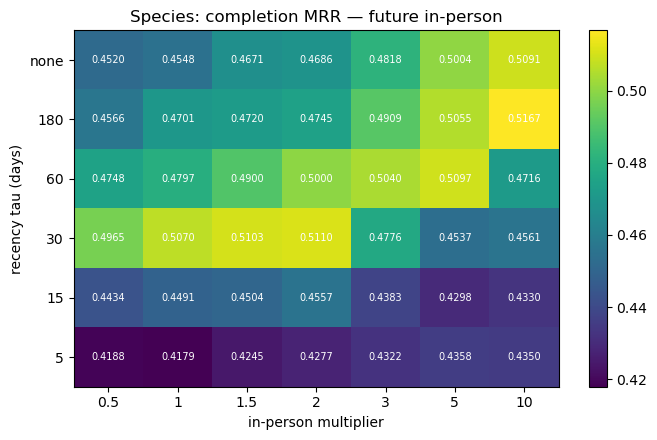

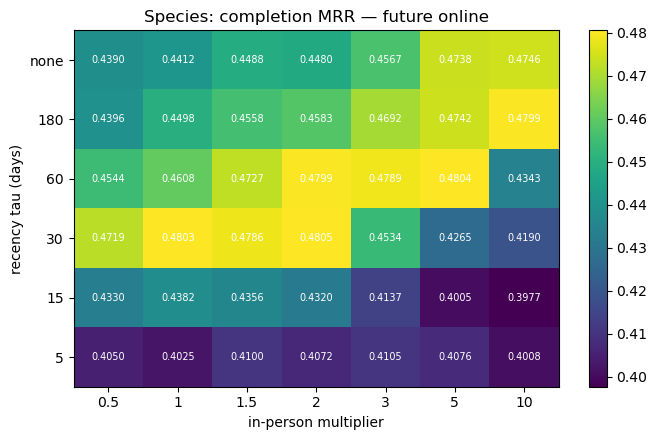

species: unweighted baseline   in_person MRR=0.4548  |  online MRR=0.4412
species: best on in_person tau=180 mult=10  ESS=6323   in_person MRR=0.5167  |  online MRR=0.4799
species: best on online  tau=30 mult=2  ESS=11339   in_person MRR=0.5110  |  online MRR=0.4805


In [6]:
grid_heatmap(species_results, "in_person", "mrr", "Species: completion MRR — future in-person")
grid_heatmap(species_results, "online", "mrr", "Species: completion MRR — future online")
best_species = report_best(species_results, "species", ["in_person", "online"])

## Species @ item grid (uniqueness-masked completion)

The deployed model. Completion respects the app's uniqueness constraint — candidates sharing a species or item with a held-in pair are masked out before ranking, exactly as in `regularization_sweep.ipynb`'s Phase 3 section.

In [7]:
train_pairs = [o.members for o in train_obs]
pair_counts = Counter(p for team in train_pairs for p in team)
pair_vocab = sorted((p for p, c in pair_counts.items() if c >= VOCAB_MIN_TEAM_COUNT),
                    key=lambda p: (p[0], p[1] or ""))
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
Vp = len(pair_vocab)
X_train_pair = teams_to_matrix(train_pairs, pair_to_idx, Vp).astype(np.int32)

species_ids = {s: k for k, s in enumerate(sorted({s for s, _ in pair_vocab}))}
item_ids = {it: k for k, it in enumerate(sorted({it for _, it in pair_vocab if it is not None}))}
pair_species_id = np.array([species_ids[s] for s, _ in pair_vocab])
pair_item_id = np.array([item_ids.get(it, -1) for _, it in pair_vocab])


def make_pair_problems(teams_full, seed):
    """Leave-one-out problems + eval matrix for in-vocab (species, item) teams."""
    rng = np.random.default_rng(seed)
    problems, kept = [], []
    for team in teams_full:
        members = sorted(team, key=lambda p: (p[0], p[1] or ""))
        if len(members) != 6 or len({s for s, _ in members}) != 6:
            continue
        if not all(p in pair_to_idx for p in members):
            continue
        kept.append(team)
        idxs = np.array([pair_to_idx[p] for p in members])
        ho = int(rng.integers(6))
        problems.append((np.delete(idxs, ho), int(idxs[ho])))
    X_eval = teams_to_matrix(kept, pair_to_idx, Vp).astype(np.int32)
    return problems, X_eval


pair_problems_in_person, Xp_in_person = make_pair_problems(test_in_person_teams, COMPLETION_SEED)
pair_problems_online, Xp_online = make_pair_problems(test_online_teams, COMPLETION_SEED + 1)
print(f"pair vocab: {Vp}")
print(f"in-person problems:  {len(pair_problems_in_person)} of {len(test_in_person_teams)} teams")
print(f"online problems: {len(pair_problems_online)} of {len(test_online_teams)} teams")


def pair_completion_metric(problems_local, J, h):
    """Leave-one-out (species, item) completion with the app's uniqueness mask."""
    rr = np.empty(len(problems_local))
    hit1 = hit5 = 0
    for n, (held_in, held_out_idx) in enumerate(problems_local):
        scores = score_ising_meanfield(held_in, J=J, h=h).copy()
        hi_sp = pair_species_id[held_in]
        hi_it = pair_item_id[held_in]
        hi_it = hi_it[hi_it >= 0]
        invalid = np.isin(pair_species_id, hi_sp) | np.isin(pair_item_id, hi_it)
        invalid[held_out_idx] = False   # true answer is valid by construction
        scores[invalid] = -np.inf
        rank = 1 + int((scores > scores[held_out_idx]).sum())
        rr[n] = 1.0 / rank
        hit1 += rank <= 1
        hit5 += rank <= 5
    N = len(problems_local)
    return float(rr.mean()), hit1 / N, hit5 / N


PAIR_EVALS = [
    ("in_person", pair_completion_metric, pair_problems_in_person, Xp_in_person),
    ("online", pair_completion_metric, pair_problems_online, Xp_online),
]

pair vocab: 780
in-person problems:  1044 of 1094 teams
online problems: 411 of 440 teams


In [8]:
pair_results = sweep_grid(X_train_pair, SPECIES_ITEM_LR_LAMBDA, PAIR_EVALS)

tau= none mult=0.5  ESS=  21598  in_person MRR=0.4624 top1=30.5% top5=64.9% pll=-11.03  |  online MRR=0.4394 top1=28.5% top5=60.8% pll=-12.30
tau= none mult=1    ESS=  22074  in_person MRR=0.4776 top1=32.7% top5=65.9% pll=-10.74  |  online MRR=0.4460 top1=29.2% top5=60.6% pll=-12.17
tau= none mult=1.5  ESS=  21674  in_person MRR=0.4932 top1=35.1% top5=66.4% pll=-10.58  |  online MRR=0.4541 top1=30.2% top5=61.3% pll=-12.10
tau= none mult=2    ESS=  20669  in_person MRR=0.5010 top1=36.1% top5=66.8% pll=-10.48  |  online MRR=0.4573 top1=30.4% top5=61.6% pll=-12.08
tau= none mult=3    ESS=  17908  in_person MRR=0.5105 top1=37.4% top5=67.2% pll=-10.31  |  online MRR=0.4648 top1=31.9% top5=61.6% pll=-12.03
tau= none mult=5    ESS=  12958  in_person MRR=0.5192 top1=38.6% top5=67.7% pll=-10.19  |  online MRR=0.4693 top1=32.8% top5=62.5% pll=-12.08
tau= none mult=10   ESS=   7298  in_person MRR=0.5244 top1=39.7% top5=66.7% pll=-10.22  |  online MRR=0.4690 top1=33.8% top5=62.5% pll=-12.34
tau=  

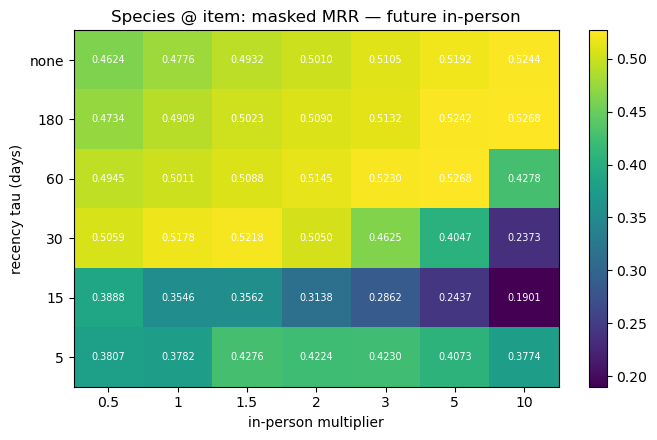

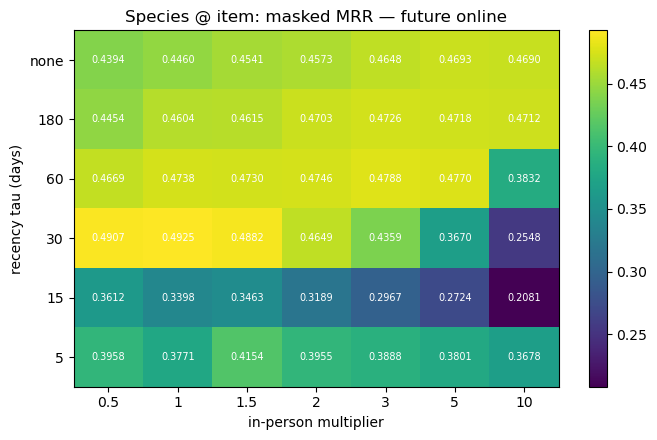

species_item: unweighted baseline   in_person MRR=0.4776  |  online MRR=0.4460
species_item: best on in_person tau=180 mult=10  ESS=6323   in_person MRR=0.5268  |  online MRR=0.4712
species_item: best on online  tau=30 mult=1  ESS=15102   in_person MRR=0.5178  |  online MRR=0.4925


In [9]:
grid_heatmap(pair_results, "in_person", "mrr", "Species @ item: masked MRR — future in-person")
grid_heatmap(pair_results, "online", "mrr", "Species @ item: masked MRR — future online")
best_pair = report_best(pair_results, "species_item", ["in_person", "online"])

## Popularity floor

sklearn's lbfgs does not penalize the intercept, so λ→∞ converges to `J = 0`, `h = logit(marginal)`: pure popularity ranking on the weighted corpus. The pairwise structure only earns the gap between a model's MRR and this floor — and a λ optimum drifting upward is partly the metric rewarding the popularity end of the spectrum. Computed per weighting cell (edit `FLOOR_CELLS`), no fit required.

In [10]:
FLOOR_CELLS = [(None, 1.0), (30.0, 3.0)]

print("popularity-only floor (J=0, h=logit weighted marginal):")
for tau, mult in FLOOR_CELLS:
    w = team_weights(train_obs, reference_date=ref_date,
                     recency_tau=tau, in_person_multiplier=mult)
    tau_s = "none" if tau is None else f"{tau:g}"
    for name, X_tr, evals in [("species", X_train, SPECIES_EVALS),
                              ("pairs  ", X_train_pair, PAIR_EVALS)]:
        m_w = np.clip((w @ X_tr) / w.sum(), 1e-9, 1 - 1e-9)
        h_pop = np.log(m_w / (1 - m_w))
        J0 = np.zeros((len(m_w), len(m_w)))
        parts = []
        for lbl, metric_fn, probs, _ in evals:
            mrr, hit1, hit5 = metric_fn(probs, J0, h_pop)
            parts.append(f"{lbl} MRR={mrr:.4f} top1={hit1:.1%} top5={hit5:.1%}")
        print(f"  {name} @ tau={tau_s:>4} mult={mult:g}:  " + "  |  ".join(parts))

popularity-only floor (J=0, h=logit weighted marginal):
  species @ tau=none mult=1:  in_person MRR=0.2644 top1=9.7% top5=50.9%  |  online MRR=0.2572 top1=10.3% top5=47.1%
  pairs   @ tau=none mult=1:  in_person MRR=0.1969 top1=6.2% top5=33.5%  |  online MRR=0.1870 top1=7.5% top5=29.2%
  species @ tau=  30 mult=3:  in_person MRR=0.2784 top1=12.0% top5=49.6%  |  online MRR=0.2600 top1=11.3% top5=46.0%
  pairs   @ tau=  30 mult=3:  in_person MRR=0.2014 top1=7.0% top5=32.5%  |  online MRR=0.1912 top1=7.5% top5=29.7%


## λ re-sweep at candidate cells

Recency decay concentrates the fit on fewer effective teams (see the ESS column), and a heavy in-person multiplier does the same — so the regularization tuned on the unweighted corpus (`regularization_sweep.ipynb`) may no longer be optimal where the weighting is aggressive.

Re-sweep λ at **several candidate cells**, not just the argmax: grid winners that sit one step from a collapsed cell (the τ≤15 cliff in the species grid) are exactly where production λ is most suspect. If stronger λ rescues the cliff region, the frontier shifts; if not, prefer a winner a step back from the edge — sub-0.01 MRR differences on these eval sizes are within noise anyway. Edit the `*_CANDIDATES` lists after reading the grids.

In [14]:
LAMBDA_GRID_SPECIES = np.logspace(0, 2, 9)   # 1 .. 100, production 10
LAMBDA_GRID_PAIR = np.logspace(-1, 1, 9)     # 0.1 .. 10, production 1

# Edit after reading the grids: the per-eval argmaxes plus safer step-back cells.
# (None, 1.0) is the control: lambda gain that appears with no weighting at all
# is the out-of-time-eval effect; gain only under weighting is the ESS effect.
SPECIES_CANDIDATES = [(None, 1.0)] + sorted(set(best_species.values()) - {(None, 1.0)}, key=str)
PAIR_CANDIDATES = [(None, 1.0)] + sorted(set(best_pair.values()) - {(None, 1.0)}, key=str)


def lambda_resweep(X_train_local, cells, lam_grid, evals, label, prod_lam):
    for tau, mult in cells:
        w = team_weights(train_obs, reference_date=ref_date,
                         recency_tau=tau, in_person_multiplier=mult)
        tau_s = "none" if tau is None else f"{tau:g}"
        print(f"{label} @ tau={tau_s} mult={mult:g}  ESS={effective_sample_size(w):.0f} "
              f"(of {len(w)} teams)")
        rows = []
        for lam in lam_grid:
            J, h = fit_pl_ising(X_train_local, C=1.0 / lam, sample_weight=w)
            r = {}
            for elabel, metric_fn, probs, X_t in evals:
                mrr, hit1, hit5 = metric_fn(probs, J, h)
                r[elabel] = (mrr, hit1, hit5, held_out_pll(X_t, J, h))
            rows.append((lam, r))
            cols = "  |  ".join(
                f"{e} MRR={r[e][0]:.4f} top5={r[e][2]:.1%} pll={r[e][3]:.2f}"
                for e, *_ in evals
            )
            print(f"  lambda={lam:7.3f}  {cols}")
        primary = evals[0][0]
        best = max(rows, key=lambda row: row[1][primary][0])
        print(f"  -> best lambda={best[0]:g} on {primary} "
              f"(MRR={best[1][primary][0]:.4f});  production lambda={prod_lam:g}\n")


lambda_resweep(X_train, SPECIES_CANDIDATES, LAMBDA_GRID_SPECIES,
               SPECIES_EVALS, "species", SPECIES_LR_LAMBDA)
lambda_resweep(X_train_pair, PAIR_CANDIDATES, LAMBDA_GRID_PAIR,
               PAIR_EVALS, "species_item", SPECIES_ITEM_LR_LAMBDA)

species @ tau=none mult=1  ESS=22074 (of 22074 teams)
  lambda=  1.000  in_person MRR=0.3956 top5=61.3% pll=-12.33  |  online MRR=0.3728 top5=55.4% pll=-15.67
  lambda=  1.778  in_person MRR=0.4043 top5=61.7% pll=-12.05  |  online MRR=0.3828 top5=55.9% pll=-14.90
  lambda=  3.162  in_person MRR=0.4094 top5=62.3% pll=-11.57  |  online MRR=0.3948 top5=56.8% pll=-13.94
  lambda=  5.623  in_person MRR=0.4328 top5=64.3% pll=-10.91  |  online MRR=0.4116 top5=57.7% pll=-12.89
  lambda= 10.000  in_person MRR=0.4548 top5=67.4% pll=-10.44  |  online MRR=0.4412 top5=59.5% pll=-12.15
  lambda= 17.783  in_person MRR=0.4878 top5=68.9% pll=-10.30  |  online MRR=0.4641 top5=62.5% pll=-11.84
  lambda= 31.623  in_person MRR=0.5040 top5=69.9% pll=-10.55  |  online MRR=0.4739 top5=64.6% pll=-11.99
  lambda= 56.234  in_person MRR=0.5061 top5=70.7% pll=-11.08  |  online MRR=0.4690 top5=64.1% pll=-12.46
  lambda=100.000  in_person MRR=0.5008 top5=69.8% pll=-11.76  |  online MRR=0.4641 top5=62.1% pll=-13.09
 

## Joint `(τ, m, λ)` check

The `(τ, m)` grids above were swept at production λ, but λ is the dominant knob and it interacts with the weighting: stronger shrinkage stabilizes small-ESS cells, so the cliff boundary moves and the argmax can too. Re-run the grid at the bracketing λ values from the re-sweep (edit the lists after reading its output) and check whether the winning cell moves.

The grid override below shadows the main `TAU_GRID` / `MULT_GRID` to keep runtime down — restore them if you rerun earlier cells afterward.

In [16]:
# SPECIES_JOINT_LAMBDAS = [17.783, 31.623, 56.234]
PAIR_JOINT_LAMBDAS = np.linspace(3, 8, 11)

# Pruned grid for the joint pass (shadows the main grids; keep (None, 1.0)
# so report_best retains its baseline row).
TAU_GRID = [None, 60.0, 30.0, 15.0]
MULT_GRID = [1.0]#, 2.0, 3.0, 5.0]

# species_by_lam = {}
# for lam in SPECIES_JOINT_LAMBDAS:
#     print(f"=== species, lambda={lam:g} ===")
#     species_by_lam[lam] = sweep_grid(X_train, lam, SPECIES_EVALS)
#     report_best(species_by_lam[lam], f"species lam={lam:g}", ["in_person", "online"])
#     print()

pair_by_lam = {}
for lam in PAIR_JOINT_LAMBDAS:
    print(f"=== species_item, lambda={lam:g} ===")
    pair_by_lam[lam] = sweep_grid(X_train_pair, lam, PAIR_EVALS)
    report_best(pair_by_lam[lam], f"species_item lam={lam:g}", ["in_person", "online"])
    print()

=== species_item, lambda=3 ===
tau= none mult=1    ESS=  22074  in_person MRR=0.5306 top1=39.9% top5=68.8% pll=-11.18  |  online MRR=0.4867 top1=34.8% top5=64.2% pll=-12.50
tau=   60 mult=1    ESS=  20005  in_person MRR=0.5506 top1=42.2% top5=71.7% pll=-10.58  |  online MRR=0.5113 top1=38.2% top5=66.9% pll=-11.95
tau=   30 mult=1    ESS=  15102  in_person MRR=0.5688 top1=44.8% top5=72.7% pll=-10.16  |  online MRR=0.5317 top1=40.6% top5=68.1% pll=-11.57
tau=   15 mult=1    ESS=   7834  in_person MRR=0.3856 top1=37.1% top5=38.4% pll=-60.08  |  online MRR=0.3573 top1=34.5% top5=35.0% pll=-61.96
species_item lam=3: unweighted baseline   in_person MRR=0.5306  |  online MRR=0.4867
species_item lam=3: best on in_person tau=30 mult=1  ESS=15102   in_person MRR=0.5688  |  online MRR=0.5317
species_item lam=3: best on online  tau=30 mult=1  ESS=15102   in_person MRR=0.5688  |  online MRR=0.5317

=== species_item, lambda=3.5 ===
tau= none mult=1    ESS=  22074  in_person MRR=0.5300 top1=39.7% top

## Shipping the result

1. **Pick the winners.** The species @ item grid decides (it's the deployed model); the species grid is the sanity cross-check. Require the chosen cell to be good on **both** eval columns — an in_person-only winner is the resemblance confound. On a tie (sub-~0.01 MRR), prefer the *milder* weighting (longer τ, smaller multiplier) and a cell that is not adjacent to a collapsed one.
2. **Set the constants**: `RECENCY_TAU_DAYS` and `IN_PERSON_WEIGHT` in `k2dex/constants.py`, plus `SPECIES_LR_LAMBDA` / `SPECIES_ITEM_LR_LAMBDA` if the re-sweep moved them materially. Both loaders and `precompute.py` pick the constants up as defaults.
3. **Rebuild artifacts**: one `scripts/precompute.py` run per model (`--tau` / `--in-person-weight` override the constants if needed), then `--generate-manifest`. Inspect `meta.json:fit` — it records `recency_tau_days` and `in_person_weight`. Commit after eyeballing.
4. **Null result is a result.** If the baseline cell wins or the grids are flat, leave the constants neutral — the machinery stays in place and v1.1 reduces to the status quo.
5. **Re-run at the M-B transition.** M-A's recency result is partly format-maturation (in-person events ran old formats until late May, and the early online meta was unsettled), so the winning τ here may overstate steady-state drift.